# Figures for the paper

Builds the main figures (Fig. 1-6) and the receptor supplement (Fig. S1) from the result tables saved by the analysis notebooks (`results/...`), plus the Parse pseudobulk cache for Fig. 1b-c. Nothing is re-analysed. Each panel is drawn independently: if a result file is missing, the panel shows which file and which notebook produce it.

Output: `figures/Fig*.pdf` and `.png` (300 dpi).

In [1]:
import os, numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
R = "results"; OUT = "figures"; CACHE = "data/parse10m/cache"
os.makedirs(OUT, exist_ok=True)
mpl.rcParams.update({"font.size": 8, "axes.titlesize": 9, "axes.labelsize": 8, "legend.fontsize": 7,
                     "xtick.labelsize": 7, "ytick.labelsize": 7, "axes.spines.top": False, "axes.spines.right": False,
                     "pdf.fonttype": 42, "font.family": "sans-serif"})
COL = {"immune": "#4C72B0", "inert": "#DD8452", "technical": "#8C8C8C", "State": "#55A868",
       "additive": "#4C72B0", "context mean": "#C44E52", "inert shift": "#DD8452", "Rhaister": "#8172B3",
       "PBS": "#8C8C8C", "same": "#4C72B0", "other": "#CCCCCC"}
INERT = ["Noggin", "Decorin", "PSPN", "GDNF", "Megalin", "PRL", "EPO", "TPO", "FGF-beta", "EGF", "HGF", "VEGF", "IGF-1"]
STRICT = ["TPO", "Megalin", "PSPN", "EPO", "EGF"]
MAIN_CT = ["B", "CD4 T", "CD8 T", "CD14 Mono", "CD16 Mono", "NK"]

def load(path, **kw):
    p = os.path.join(R, path)
    return pd.read_csv(p, **kw) if os.path.exists(p) else None
def missing(ax, what, nb):
    ax.axis("off"); ax.text(0.5, 0.5, f"missing: {what}\n(run {nb})", ha="center", va="center", fontsize=7, color="red")
#def letter(ax, s): ax.text(-0.12, 1.08, s, transform=ax.transAxes, fontsize=11, fontweight="bold", va="top")
def letter(ax, s): ax.text(-0.12, 1.08, s.upper(), transform=ax.transAxes, fontsize=11, fontweight="bold", va="top")
def save(fig, name):
    fig.savefig(f"{OUT}/{name}.pdf", bbox_inches="tight"); fig.savefig(f"{OUT}/{name}.png", dpi=300, bbox_inches="tight")
    plt.show(); print("saved", name)

print("ok")

ok


## Fig. 1 - Design and the control-well shift

median size vs PBS / vs inert: 3.19 / 2.84 | median pairwise cosine vs PBS / vs inert: 0.28 / -0.11


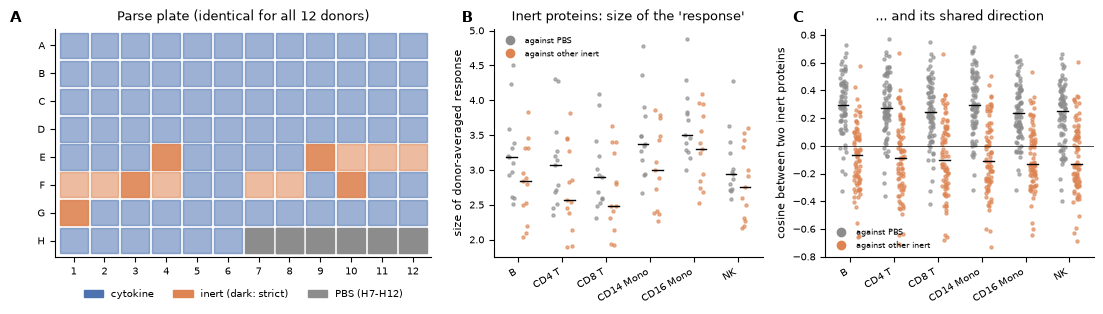

saved Fig1_design_and_control_shift


In [2]:
fig, ax = plt.subplots(1, 3, figsize=(11, 3.2), gridspec_kw={"width_ratios": [1.4, 1, 1]})
# a: Parse plate layout
w = load("dictionary_position/cytokine_wells.csv", index_col=0)
a = ax[0]; letter(a, "a")
if w is None: missing(a, "cytokine_wells.csv", "dictionary_position_check")
else:
    rows = list("ABCDEFGH")
    for cyto, r in w.iterrows():
        y = rows.index(str(r.row)); x = int(r.col)
        c = COL["inert"] if cyto in INERT else (COL["PBS"] if cyto == "PBS" else COL["immune"])
        a.add_patch(plt.Rectangle((x - 0.45, 7 - y - 0.45), 0.9, 0.9, color=c, alpha=0.9 if cyto in STRICT or cyto == "PBS" else 0.55))
    for pw in ["H7", "H8", "H9", "H10", "H11", "H12"]:
        a.add_patch(plt.Rectangle((int(pw[1:]) - 0.45, -0.45), 0.9, 0.9, color=COL["PBS"]))
    a.set_xlim(0.4, 12.6); a.set_ylim(-0.6, 7.6); a.set_xticks(range(1, 13)); a.set_yticks(range(8)); a.set_yticklabels(rows[::-1])
    a.set_title("Parse plate (identical for all 12 donors)")
    a.legend(handles=[mpl.patches.Patch(color=COL["immune"], label="cytokine"), mpl.patches.Patch(color=COL["inert"], label="inert (dark: strict)"),
                      mpl.patches.Patch(color=COL["PBS"], label="PBS (H7-H12)")], loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=3, frameon=False)
# b-c: inert proteins against PBS vs against the other inert proteins (donor-averaged responses)
try:
    sums = np.load(f"{CACHE}/pb_sums.npy"); meta = pd.read_pickle(f"{CACHE}/pb_meta.pkl").reset_index(drop=True)
    key = meta[["donor", "cell_type", "cytokine"]].astype(str).agg("|".join, axis=1); codes, uniq = pd.factorize(key)
    FULL = np.zeros((len(uniq), sums.shape[1])); np.add.at(FULL, codes, sums)
    NC = np.bincount(codes, weights=meta.n_cells.to_numpy(), minlength=len(uniq))
    IDX = {tuple(u.split("|")): i for i, u in enumerate(uniq) if NC[i] >= 50}
    lc = lambda x: np.log1p(x / max(x.sum(), 1) * 1e6)
    rows_b, rows_c = [], []
    for ct in MAIN_CT:
        donors = sorted({k[0] for k in IDX if k[1] == ct and k[2] == "PBS"})
        inert = [c for c in INERT if sum((d, ct, c) in IDX for d in donors) >= 8]
        P = {(d, c): lc(FULL[IDX[(d, ct, c)]]) for d in donors for c in inert + ["PBS"] if (d, ct, c) in IDX}
        pbs_mean = np.mean([P[(d, "PBS")] for d in donors], 0); gidx = np.argsort(pbs_mean)[::-1][:2000]
        vs_pbs, vs_inert = {}, {}
        for c in inert:
            a_, b_ = [], []
            for d in donors:
                if (d, c) not in P: continue
                others = [P[(d, k)] for k in inert if k != c and (d, k) in P]
                a_.append((P[(d, c)] - P[(d, "PBS")])[gidx]); b_.append((P[(d, c)] - np.mean(others, 0))[gidx])
            vs_pbs[c], vs_inert[c] = np.mean(a_, 0), np.mean(b_, 0)
            rows_b.append(dict(cell_type=ct, cytokine=c, strict=c in STRICT, vs_PBS=np.linalg.norm(vs_pbs[c]), vs_inert=np.linalg.norm(vs_inert[c])))
        cos = lambda x, y: float(x @ y / (np.linalg.norm(x) * np.linalg.norm(y)))
        for i, c1 in enumerate(inert):
            for c2 in inert[i + 1:]:
                rows_c.append(dict(cell_type=ct, pair=f"{c1}/{c2}", vs_PBS=cos(vs_pbs[c1], vs_pbs[c2]), vs_inert=cos(vs_inert[c1], vs_inert[c2])))
    B = pd.DataFrame(rows_b); Cc = pd.DataFrame(rows_c)
    B.to_csv(f"{OUT}/fig1b_inert_size.csv", index=False); Cc.to_csv(f"{OUT}/fig1c_inert_pairwise_cosine.csv", index=False)
    for a, D, lab, L, ttl in [(ax[1], B, "size of donor-averaged response", "b", "Inert proteins: size of the 'response'"),
                              (ax[2], Cc, "cosine between two inert proteins", "c", "... and its shared direction")]:
        letter(a, L)
        for i, ct in enumerate(MAIN_CT):
            g = D[D.cell_type == ct]
            for j, (col, cc) in enumerate([("vs_PBS", COL["PBS"]), ("vs_inert", COL["inert"])]):
                x = i + (j - 0.5) * 0.32
                a.scatter(np.full(len(g), x) + np.random.uniform(-0.07, 0.07, len(g)), g[col], s=5, color=cc, alpha=0.6)
                a.plot([x - 0.12, x + 0.12], [g[col].median()] * 2, color="k", lw=1)
        a.set_xticks(range(len(MAIN_CT))); a.set_xticklabels(MAIN_CT, rotation=30, ha="right"); a.set_ylabel(lab); a.set_title(ttl)
        a.legend(handles=[mpl.lines.Line2D([], [], marker="o", ls="", color=COL["PBS"], label="against PBS"),
                          mpl.lines.Line2D([], [], marker="o", ls="", color=COL["inert"], label="against other inert")], frameon=False, fontsize=6)
    ax[2].axhline(0, color="k", lw=0.5)
    print("median size vs PBS / vs inert:", B.vs_PBS.median().round(2), "/", B.vs_inert.median().round(2),
          "| median pairwise cosine vs PBS / vs inert:", Cc.vs_PBS.median().round(2), "/", Cc.vs_inert.median().round(2))
except Exception as e:
    missing(ax[1], f"pseudobulk cache ({e})", "aim1_compass_parse"); missing(ax[2], "pseudobulk cache", "aim1_compass_parse")
plt.tight_layout(); save(fig, "Fig1_design_and_control_shift")

## Fig. 2 - Well noise and shared-well coordination (Parse and OP3)

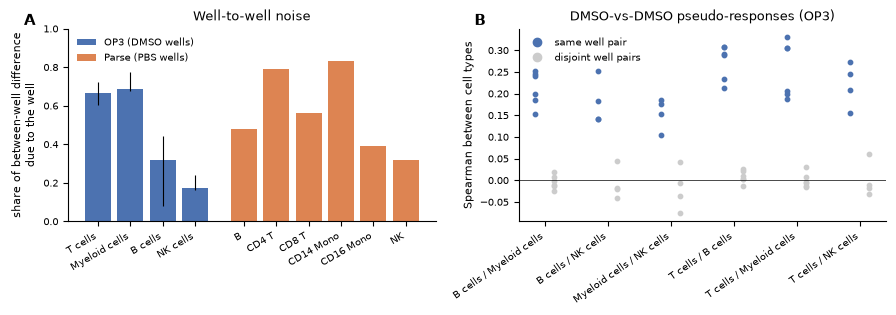

saved Fig2_well_noise


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
wn = load("op3_audit/dmso_well_noise.csv")
a = ax[0]; letter(a, "a")
if wn is None: missing(a, "op3_audit/dmso_well_noise.csv", "op3_analysis")
else:
    m = wn.groupby("cell_type").well_noise_frac.agg(["median", "min", "max"]).reindex(["T cells", "Myeloid cells", "B cells", "NK cells"]).dropna()
    parse = pd.Series(dtype=float)
    try:
        ws = np.load(f"{CACHE}/pbs_wells.npz")["sums"]; wm = pd.read_pickle(f"{CACHE}/pbs_wells_meta.pkl").reset_index(drop=True)
        lc = lambda x: np.log1p(x / max(x.sum(), 1) * 1e6); frac = {}
        for (d, ct), g in wm.groupby(["donor", "cell_type"]):
            H = {}
            for wl, gw in g.groupby("well"):
                h = [gw[gw.half == k] for k in (0, 1)]
                if all(x.n_cells.sum() >= 20 for x in h): H[wl] = [lc(ws[x.index.to_numpy()].sum(0).astype(float)) for x in h]
            if len(H) < 3: continue
            gi = np.argsort(np.mean([v[0] for v in H.values()], 0))[::-1][:2000]
            within = np.mean([np.sum((v[0][gi] - v[1][gi]) ** 2) for v in H.values()])
            between = np.mean([np.sum((H[x][0][gi] - H[y][1][gi]) ** 2) for x in H for y in H if x != y])
            frac.setdefault(ct, []).append((between - within) / between)
        parse = pd.Series({ct: np.median(v) for ct, v in frac.items()}).reindex([c for c in MAIN_CT if c in frac])
    except Exception as e:
        print("Parse PBS-well cache not found:", e)
    x = np.arange(len(m)); a.bar(x, m["median"], color=COL["immune"], label="OP3 (DMSO wells)")
    a.errorbar(x, m["median"], yerr=[m["median"] - m["min"], m["max"] - m["median"]], fmt="none", color="k", lw=0.8)
    a.bar(np.arange(len(parse)) + len(m) + 0.5, parse.values, color=COL["inert"], label="Parse (PBS wells)")
    a.set_xticks(list(x) + list(np.arange(len(parse)) + len(m) + 0.5)); a.set_xticklabels(list(m.index) + list(parse.index), rotation=30, ha="right")
    a.set_ylabel("share of between-well difference\ndue to the well"); a.set_ylim(0, 1); a.legend(frameon=False)
    a.set_title("Well-to-well noise")
co = load("op3_audit/dmso_shared_well_coordination.csv")
a = ax[1]; letter(a, "b")
if co is None: missing(a, "op3_audit/dmso_shared_well_coordination.csv", "op3_analysis")
else:
    pairs = sorted(co.pair.unique())
    for i, p in enumerate(pairs):
        g = co[co.pair == p]
        a.scatter(np.full(len(g), i - 0.15), g.same_pair, s=10, color=COL["same"]); a.scatter(np.full(len(g), i + 0.15), g.different_pairs, s=10, color=COL["other"])
    a.axhline(0, color="k", lw=0.5); a.set_xticks(range(len(pairs))); a.set_xticklabels(pairs, rotation=35, ha="right")
    a.set_ylabel("Spearman between cell types"); a.set_title("DMSO-vs-DMSO pseudo-responses (OP3)")
    a.legend(handles=[mpl.lines.Line2D([], [], marker="o", ls="", color=COL["same"], label="same well pair"),
                      mpl.lines.Line2D([], [], marker="o", ls="", color=COL["other"], label="disjoint well pairs")], frameon=False)
plt.tight_layout(); save(fig, "Fig2_well_noise")

## Fig. 3 - Estimator, cell-number and batch biases; simulations

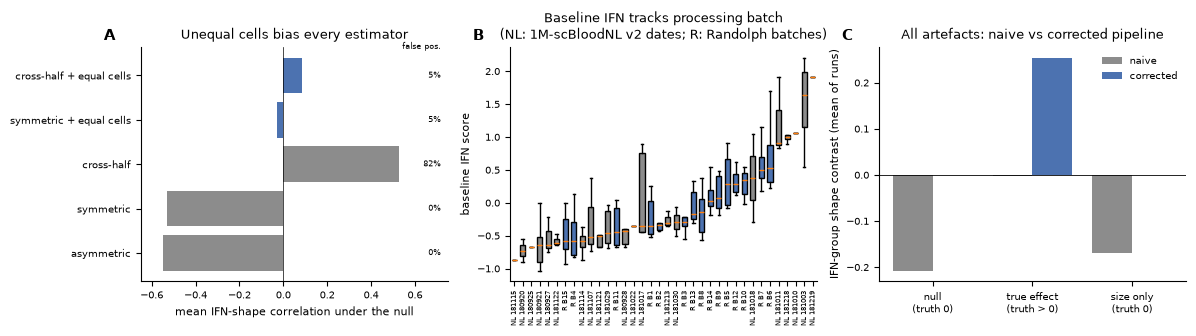

saved Fig3_biases_and_simulation


In [4]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3.4))
sim = load("aim1_simulation/simulation_replicates.csv")
a = ax[0]; letter(a, "a")
if sim is None: missing(a, "simulation_replicates.csv", "aim1_simulation")
else:
    e1 = sim[sim.experiment.str.startswith("E1")]
    s = e1.groupby("analysis").agg(rho=("rho_ifn_shape", "mean"), fp=("sig_pos", "mean")).reindex(
        ["asymmetric", "symmetric", "cross-half", "symmetric + equal cells", "cross-half + equal cells"])
    a.barh(range(len(s)), s.rho, color=[COL["technical"]] * 3 + [COL["immune"]] * 2)
    a.axvline(0, color="k", lw=0.5); a.set_yticks(range(len(s))); a.set_yticklabels(s.index)
    a.set_xlabel("mean IFN-shape correlation under the null"); a.set_title("Unequal cells bias every estimator")
    for i, f_ in enumerate(s.fp): a.text(0.72, i, f"{f_:.0%}", va="center", ha="right", fontsize=6)
    a.text(0.72, len(s) - 0.4, "false pos.", ha="right", fontsize=6); a.set_xlim(-0.65, 0.75)
a = ax[1]; letter(a, "b")
sc = load("aim1_replication/ifn_score_by_date.csv"); rd = load("aim1_replication3/randolph_donor_ifn.csv")
if sc is None and rd is None: missing(a, "ifn_score_by_date.csv / randolph_donor_ifn.csv", "replication notebooks")
else:
    groups, labels = [], []
    if sc is not None:
        v2 = sc[sc.chem == "V2"] if "chem" in sc else sc
        for d, g in v2.groupby("date"): groups.append(g.ifn_score.values); labels.append(f"NL {d}")
    if rd is not None:
        for b, g in rd.groupby("batch"): groups.append(g.ifn_score.values); labels.append(f"R {b}")
    order = np.argsort([np.median(g) for g in groups])
    bp_ = a.boxplot([groups[i] for i in order], widths=0.6, showfliers=False, patch_artist=True)
    for patch, i in zip(bp_["boxes"], order): patch.set_facecolor(COL["technical"] if labels[i].startswith("NL") else COL["immune"])
    a.set_xticks(range(1, len(order) + 1)); a.set_xticklabels([labels[i] for i in order], rotation=90, fontsize=5)
    a.set_ylabel("baseline IFN score"); a.set_title("Baseline IFN tracks processing batch\n(NL: 1M-scBloodNL v2 dates; R: Randolph batches)")
a = ax[2]; letter(a, "c")
if sim is None: missing(a, "simulation_replicates.csv", "aim1_simulation")
else:
    e5 = sim[sim.experiment.str.startswith("E5")]
    s = e5.groupby(["experiment", "analysis"]).ifn_contrast_shape.mean().unstack()
    lab = {e: ("null\n(truth 0)" if "null" in e else ("true effect\n(truth > 0)" if "true" in e else "size only\n(truth 0)")) for e in s.index}
    order_ = sorted(s.index, key=lambda e: ("null" not in e, "size" in e))
    s = s.loc[order_]; x = np.arange(len(s))
    a.bar(x - 0.2, s["naive"], 0.4, color=COL["technical"], label="naive"); a.bar(x + 0.2, s["corrected"], 0.4, color=COL["immune"], label="corrected")
    a.axhline(0, color="k", lw=0.6); a.set_xticks(x); a.set_xticklabels([lab[e] for e in s.index])
    a.set_ylabel("IFN-group shape contrast (mean of runs)"); a.set_title("All artefacts: naive vs corrected pipeline"); a.legend(frameon=False)
plt.tight_layout(); save(fig, "Fig3_biases_and_simulation")

## Fig. 4 - Audits of published analyses (Zahid; OP3 targets; DEG counts)

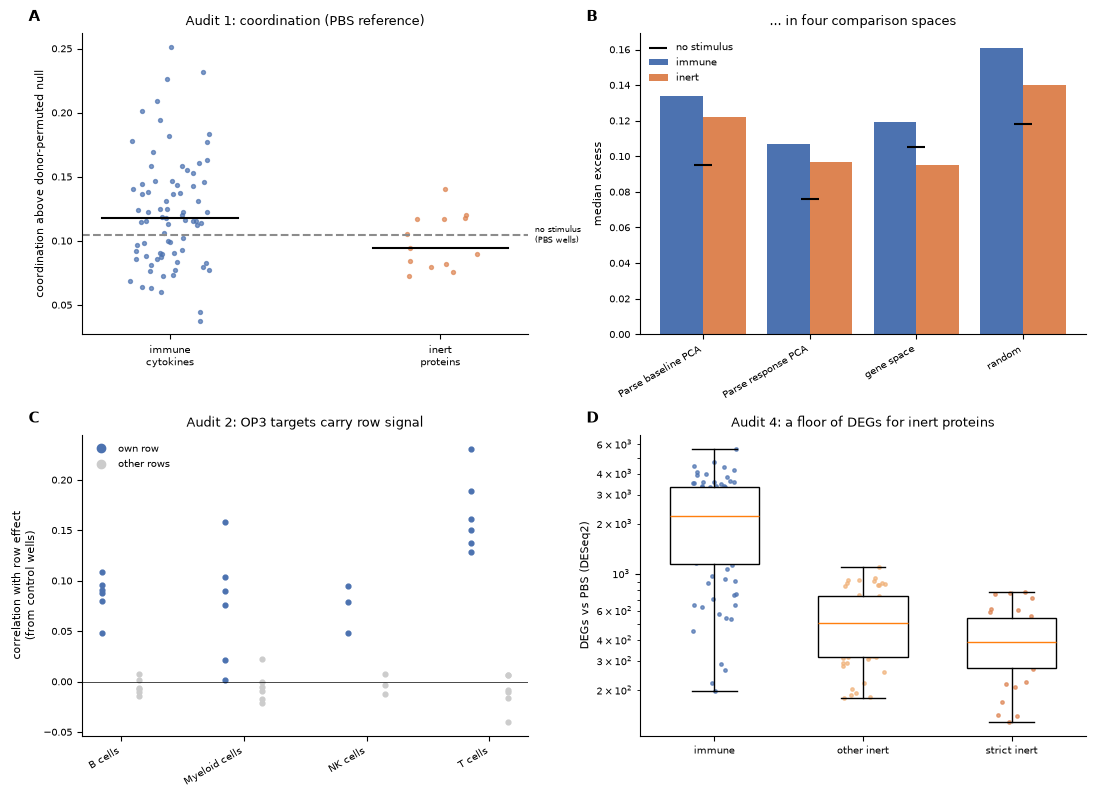

saved Fig4_audits_2x2


In [10]:
fig, ax = plt.subplots(2, 2, figsize=(11, 8)); ax = ax.ravel()
co = load("aim1_zahid_audit/coordination_per_cytokine.csv"); tech = load("aim1_zahid_audit/pbs_well_pseudo_response.csv")
a = ax[0]; letter(a, "a")
if co is None: missing(a, "coordination_per_cytokine.csv", "aim1_zahid_audit")
else:
    d = co[co.reference == "PBS"]
    for j, (g, lab) in enumerate([(d[~d.inert], "immune"), (d[d.inert], "inert")]):
        a.scatter(np.full(len(g), j) + np.random.uniform(-0.15, 0.15, len(g)), g.excess, s=8, color=COL[lab], alpha=0.7)
        a.plot([j - 0.25, j + 0.25], [g.excess.median()] * 2, color="k")
    if tech is not None:
        t = float(tech.observed.iloc[0] - tech.null_median.iloc[0]); a.axhline(t, color=COL["technical"], ls="--"); a.text(1.35, t, "no stimulus\n(PBS wells)", fontsize=6, va="center")
    a.set_xticks([0, 1]); a.set_xticklabels(["immune\ncytokines", "inert\nproteins"]); a.set_ylabel("coordination above donor-permuted null")
    a.set_title("Audit 1: coordination (PBS reference)")
sp_ = load("aim1_zahid_audit/coordination_by_space_summary.csv")
a = ax[1]; letter(a, "b")
if sp_ is None: missing(a, "coordination_by_space_summary.csv", "aim1_zahid_audit (8)")
else:
    sp_ = sp_[sp_.reference == "PBS"] if "reference" in sp_ else sp_
    x = np.arange(len(sp_)); a.bar(x - 0.2, sp_.immune_excess, 0.4, color=COL["immune"], label="immune"); a.bar(x + 0.2, sp_.inert_excess, 0.4, color=COL["inert"], label="inert")
    a.scatter(x, sp_.pbs_well_excess, color="k", marker="_", s=150, label="no stimulus", zorder=3)
    a.set_xticks(x); a.set_xticklabels([s.split(" (")[0] for s in sp_.space], rotation=30, ha="right"); a.set_ylabel("median excess"); a.legend(frameon=False)
    a.set_title("... in four comparison spaces")
rc = load("op3_benchmark_audit/row_contamination.csv")
a = ax[2]; letter(a, "c")
if rc is None: missing(a, "row_contamination.csv", "op3_benchmark_audit")
else:
    cts = sorted(rc.cell_type.unique())
    for i, ct in enumerate(cts):
        g = rc[rc.cell_type == ct]
        a.scatter(np.full(len(g), i - 0.15), g.matched, s=12, color=COL["same"]); a.scatter(np.full(len(g), i + 0.15), g.other_rows, s=12, color=COL["other"])
    a.axhline(0, color="k", lw=0.5); a.set_xticks(range(len(cts))); a.set_xticklabels(cts, rotation=30, ha="right")
    a.set_ylabel("correlation with row effect\n(from control wells)"); a.set_title("Audit 2: OP3 targets carry row signal")
    a.legend(handles=[mpl.lines.Line2D([], [], marker="o", ls="", color=COL["same"], label="own row"),
                      mpl.lines.Line2D([], [], marker="o", ls="", color=COL["other"], label="other rows")], frameon=False)
de = load("dictionary_position/deseq2_deg_counts.csv")
a = ax[3]; letter(a, "d")
if de is None: missing(a, "deseq2_deg_counts.csv", "dictionary_position_check (2)")
else:
    d = de[de.reference == "PBS"].copy(); d["group"] = np.where(d.cytokine.isin(STRICT), "strict inert", np.where(d.inert, "other inert", "immune"))
    order = ["immune", "other inert", "strict inert"]; cols = [COL["immune"], "#F0B27A", COL["inert"]]
    a.boxplot([d[d.group == g].n_deg for g in order], widths=0.6, showfliers=False, patch_artist=True,
              boxprops=dict(facecolor="white"))
    for i, (g, c) in enumerate(zip(order, cols)):
        v = d[d.group == g].n_deg; a.scatter(np.full(len(v), i + 1) + np.random.uniform(-0.15, 0.15, len(v)), v, s=6, color=c, alpha=0.7)
    a.set_yscale("log"); a.set_xticks([1, 2, 3]); a.set_xticklabels(order); a.set_ylabel("DEGs vs PBS (DESeq2)")
    a.set_title("Audit 4: a floor of DEGs for inert proteins")
plt.tight_layout(); save(fig, "Fig4_audits")

## Fig. 5 - Evaluation of prediction models (ceiling, Rhaister, State)

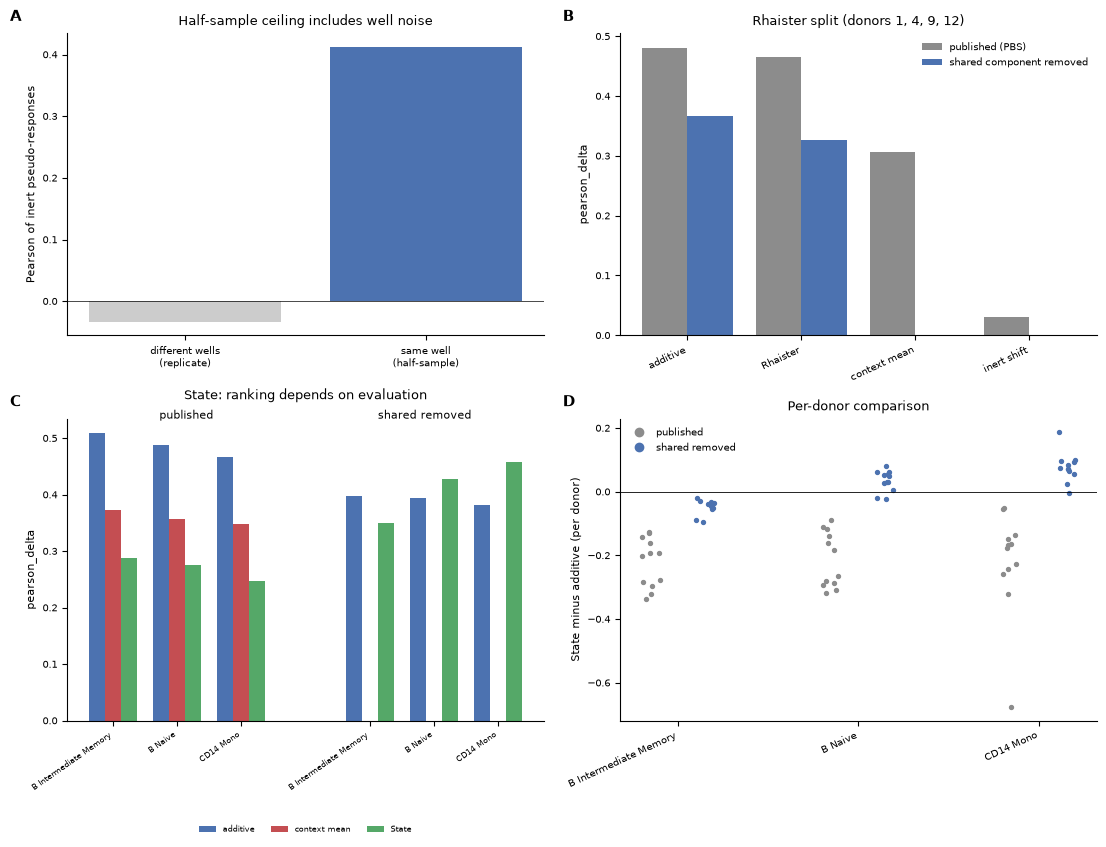

saved Fig5_model_evaluation_2x2


In [11]:
fig, ax = plt.subplots(2, 2, figsize=(11, 8.5)); ax = ax.ravel()
ce = load("aim1_benchmark_audit/ceiling_same_vs_different_well.csv")
a = ax[0]; letter(a, "a")
if ce is None: missing(a, "ceiling_same_vs_different_well.csv", "aim1_benchmark_audit (3)")
else:
    ce = ce.set_index(ce.columns[0]); vals = ce["mean"]
    a.bar(range(len(vals)), vals.values, color=[COL["other"] if "different" in i else COL["same"] for i in vals.index])
    a.set_xticks(range(len(vals))); a.set_xticklabels([i.replace(" (", "\n(") for i in vals.index]); a.axhline(0, color="k", lw=0.5)
    a.set_ylabel("Pearson of inert pseudo-responses"); a.set_title("Half-sample ceiling includes well noise")
rh = load("rhaister_rescoring/scores_per_context.csv")
a = ax[1]; letter(a, "b")
if rh is None: missing(a, "rhaister_rescoring/scores_per_context.csv", "rhaister_rescoring")
else:
    s = rh.groupby("model")[["pbs", "inert"]].mean().reindex(["additive", "Rhaister", "context mean", "inert shift"])
    x = np.arange(len(s)); a.bar(x - 0.2, s.pbs, 0.4, color=COL["technical"], label="published (PBS)"); a.bar(x + 0.2, s.inert, 0.4, color=COL["immune"], label="shared component removed")
    a.set_xticks(x); a.set_xticklabels(s.index, rotation=25, ha="right"); a.set_ylabel("pearson_delta"); a.legend(frameon=False)
    a.set_title("Rhaister split (donors 1, 4, 9, 12)")
st = load("state_rescoring/scores_per_context.csv")
a = ax[2]; letter(a, "c")
if st is None: missing(a, "state_rescoring/scores_per_context.csv", "state_rescoring")
else:
    st = st[st.cell_type != "Plasmablast"]
    s = st.groupby(["cell_type", "model"])[["pbs", "inert"]].mean().reset_index()
    cts = sorted(s.cell_type.unique()); models = ["additive", "context mean", "State"]; bw = 0.25
    xt, xl = [], []
    for k, metric in enumerate(["pbs", "inert"]):
        base = k * (len(cts) + 1)
        for j, m in enumerate(models):
            v = [s[(s.cell_type == ct) & (s.model == m)][metric].values[0] for ct in cts]
            a.bar(np.arange(len(cts)) + base + (j - 1) * bw, v, bw, color=COL[m], label=m if k == 0 else None)
        xt += list(np.arange(len(cts)) + base); xl += [c.replace("_", " ") for c in cts]
    a.set_xticks(xt); a.set_xticklabels(xl, rotation=35, ha="right", fontsize=6)
    a.text(0.25, 1.0, "published", transform=a.transAxes, ha="center"); a.text(0.75, 1.0, "shared removed", transform=a.transAxes, ha="center")
    a.set_ylabel("pearson_delta"); a.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.32), ncol=3, fontsize=6); a.set_title("State: ranking depends on evaluation", pad=14)
a = ax[3]; letter(a, "d")
if st is None: missing(a, "state_rescoring/scores_per_context.csv", "state_rescoring")
else:
    rows = []
    for (ct, metric), g in st.melt(id_vars=["cell_type", "model", "donor", "cytokine"], value_vars=["pbs", "inert"], var_name="metric").groupby(["cell_type", "metric"]):
        w = g.pivot_table(index=["donor", "cytokine"], columns="model", values="value")
        dd = (w["State"] - w["additive"]).groupby(level="donor").mean()
        for dn, v in dd.items(): rows.append(dict(cell_type=ct, metric=metric, diff=v))
    D = pd.DataFrame(rows); cts = sorted(D.cell_type.unique())
    for i, ct in enumerate(cts):
        for k, (metric, c) in enumerate([("pbs", COL["technical"]), ("inert", COL["immune"])]):
            v = D[(D.cell_type == ct) & (D.metric == metric)]["diff"]
            a.scatter(np.full(len(v), i + (k - 0.5) * 0.3) + np.random.uniform(-0.05, 0.05, len(v)), v, s=8, color=c)
    a.axhline(0, color="k", lw=0.6); a.set_xticks(range(len(cts))); a.set_xticklabels([c.replace("_", " ") for c in cts], rotation=25, ha="right")
    a.set_ylabel("State minus additive (per donor)"); a.set_title("Per-donor comparison")
    a.legend(handles=[mpl.lines.Line2D([], [], marker="o", ls="", color=COL["technical"], label="published"),
                      mpl.lines.Line2D([], [], marker="o", ls="", color=COL["immune"], label="shared removed")], frameon=False)
plt.tight_layout(); save(fig, "Fig5_model_evaluation")

## Fig. 6 - Case study: baseline interferon; replication

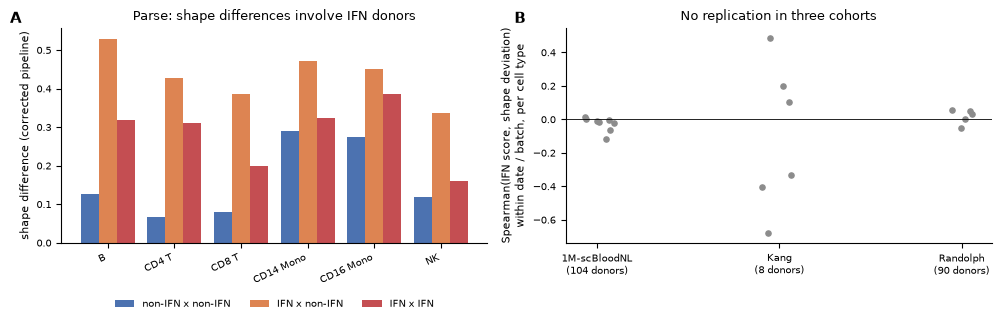

saved Fig6_ifn_case_study


In [7]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
bp = load("aim1/corrected_by_pair.csv")
a = ax[0]; letter(a, "a")
if bp is None: missing(a, "aim1/corrected_by_pair.csv", "aim1_compass_parse (13)")
else:
    if "pair" not in bp.columns: bp = bp.rename(columns={bp.columns[1]: "pair"})
    cts = [c for c in MAIN_CT if c in set(bp.cell_type)]; pairs = ["non-IFN x non-IFN", "IFN x non-IFN", "IFN x IFN"]
    cols = [COL["immune"], COL["inert"], COL["context mean"]]
    for j, (p, c) in enumerate(zip(pairs, cols)):
        v = [bp[(bp.cell_type == ct) & (bp.pair == p)]["shape"].values for ct in cts]
        a.bar(np.arange(len(cts)) + (j - 1) * 0.27, [x[0] if len(x) else np.nan for x in v], 0.27, color=c, label=p)
    a.set_xticks(range(len(cts))); a.set_xticklabels(cts, rotation=25, ha="right"); a.set_ylabel("shape difference (corrected pipeline)")
    a.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=3); a.set_title("Parse: shape differences involve IFN donors")
a = ax[1]; letter(a, "b")
nl = load("aim1_replication/corrected_summary.csv"); kg = load("aim1_replication2/kang_tests.csv"); rn = load("aim1_replication3/randolph_tests.csv")
pts = []
if nl is not None and "rho_shape_within_date" in nl: pts += [("1M-scBloodNL", r.rho_shape_within_date) for r in nl.itertuples()]
if kg is not None: pts += [("Kang", r.rho_shape) for r in kg.itertuples()]
if rn is not None: pts += [("Randolph", r.rho_shape) for r in rn[rn.test == "within batch"].itertuples()]
if not pts: missing(a, "replication result tables", "replication notebooks")
else:
    P = pd.DataFrame(pts, columns=["cohort", "rho"]); coh = ["1M-scBloodNL", "Kang", "Randolph"]
    for i, c in enumerate(coh):
        v = P[P.cohort == c].rho; a.scatter(np.full(len(v), i) + np.random.uniform(-0.1, 0.1, len(v)), v, s=14, color=COL["technical"])
    a.axhline(0, color="k", lw=0.6); a.set_xticks(range(len(coh))); a.set_xticklabels(["1M-scBloodNL\n(104 donors)", "Kang\n(8 donors)", "Randolph\n(90 donors)"])
    a.set_ylabel("Spearman(IFN score, shape deviation)\nwithin date / batch, per cell type"); a.set_title("No replication in three cohorts")
plt.tight_layout(); save(fig, "Fig6_ifn_case_study")

## Fig. S1 - Receptor expression of the inert proteins

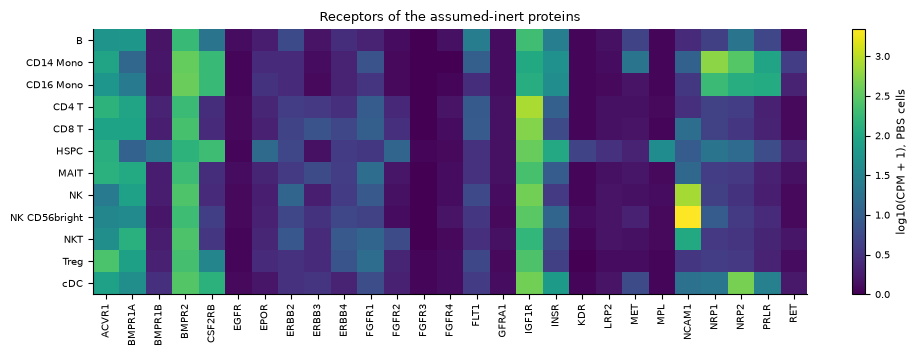

saved FigS1_receptors


In [8]:
rec = load("inert_receptors/receptor_cpm_by_celltype.csv", index_col=0)
fig, a = plt.subplots(figsize=(10, 3.6))
if rec is None: missing(a, "receptor_cpm_by_celltype.csv", "inert_receptor_check")
else:
    im = a.imshow(np.log10(rec.values + 1), aspect="auto", cmap="viridis")
    a.set_xticks(range(rec.shape[1])); a.set_xticklabels(rec.columns, rotation=90); a.set_yticks(range(rec.shape[0])); a.set_yticklabels(rec.index)
    plt.colorbar(im, ax=a, label="log10(CPM + 1), PBS cells"); a.set_title("Receptors of the assumed-inert proteins")
plt.tight_layout(); save(fig, "FigS1_receptors")

## Fig. S2 - Shared response structure and donor differences (COMPASS on Parse)

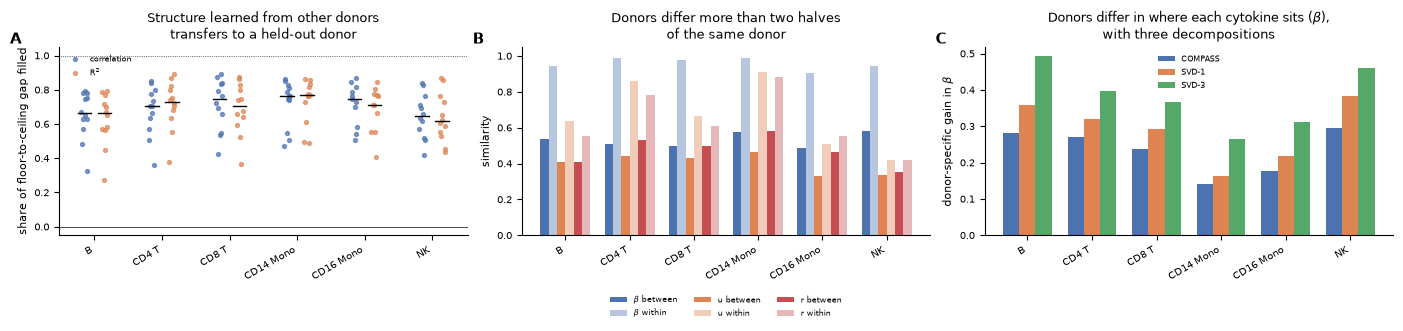

saved FigS2_shared_structure


In [9]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
lodo = load("aim1/lodo_per_donor.csv")
a = ax[0]; letter(a, "a")
if lodo is None: missing(a, "aim1/lodo_per_donor.csv", "aim1_compass_parse")
else:
    cts = [c for c in MAIN_CT if c in set(lodo.cell_type)]
    for k, (col, c, lab) in enumerate([("pop_gap", COL["immune"], "correlation"), ("pop_r2gap", COL["inert"], "R$^2$")]):
        for i, ct in enumerate(cts):
            v = lodo[lodo.cell_type == ct][col].dropna()
            x = i + (k - 0.5) * 0.3
            a.scatter(np.full(len(v), x) + np.random.uniform(-0.05, 0.05, len(v)), v, s=8, color=c, alpha=0.7, label=lab if i == 0 else None)
            a.plot([x - 0.1, x + 0.1], [v.median()] * 2, color="k", lw=1)
    a.axhline(0, color="k", lw=0.5); a.axhline(1, color="k", lw=0.5, ls=":")
    a.set_xticks(range(len(cts))); a.set_xticklabels(cts, rotation=30, ha="right")
    a.set_ylabel("share of floor-to-ceiling gap filled"); a.set_title("Structure learned from other donors\ntransfers to a held-out donor")
    a.legend(frameon=False, fontsize=6)
bw = load("aim1/between_vs_within.csv", header=[0, 1], index_col=0)
a = ax[1]; letter(a, "b")
if bw is None: missing(a, "aim1/between_vs_within.csv", "aim1_compass_parse")
else:
    cts = [c for c in MAIN_CT if c in bw.index]; comps = ["beta", "u", "r"]
    names = {"beta": r"$\beta$", "u": "u", "r": "r"}
    w = 0.13
    for j, comp in enumerate(comps):
        for k, (lvl, alpha) in enumerate([("between", 1.0), ("within", 0.4)]):
            vals = [bw.loc[ct, (lvl, comp)] for ct in cts]
            a.bar(np.arange(len(cts)) + (j * 2 + k - 2.5) * w, vals, w, color=[COL["immune"], COL["inert"], COL["context mean"]][j],
                  alpha=alpha, label=f"{names[comp]} {lvl}")
    a.set_xticks(range(len(cts))); a.set_xticklabels(cts, rotation=30, ha="right"); a.set_ylim(0, 1.05)
    a.set_ylabel("similarity"); a.set_title("Donors differ more than two halves\nof the same donor"); a.legend(frameon=False, fontsize=6, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.28))
rob = load("aim1/robustness_lodo.csv")
a = ax[2]; letter(a, "c")
if rob is None: missing(a, "aim1/robustness_lodo.csv", "aim1_compass_parse")
else:
    MNAME = {"compass": "COMPASS", "svd1": "SVD-1", "svd3": "SVD-3"}
    rob = rob.assign(method=rob.method.map(lambda m: MNAME.get(m, m)))
    methods = [m for m in ["COMPASS", "SVD-1", "SVD-3"] if m in set(rob.method)] or sorted(rob.method.unique())
    cts = [c for c in MAIN_CT if c in set(rob.cell_type)]
    s = rob.groupby(["method", "cell_type"]).specific_beta.mean()
    for j, m in enumerate(methods):
        a.bar(np.arange(len(cts)) + (j - (len(methods) - 1) / 2) * 0.25, [s.get((m, ct), np.nan) for ct in cts], 0.25,
              color=[COL["immune"], COL["inert"], COL["State"]][j % 3], label=m)
    a.axhline(0, color="k", lw=0.5); a.set_xticks(range(len(cts))); a.set_xticklabels(cts, rotation=30, ha="right")
    a.set_ylabel(r"donor-specific gain in $\beta$"); a.set_title(r"Donors differ in where each cytokine sits ($\beta$)," + "\nwith three decompositions")
    a.legend(frameon=False, fontsize=6)
plt.tight_layout(); save(fig, "FigS2_shared_structure")